<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


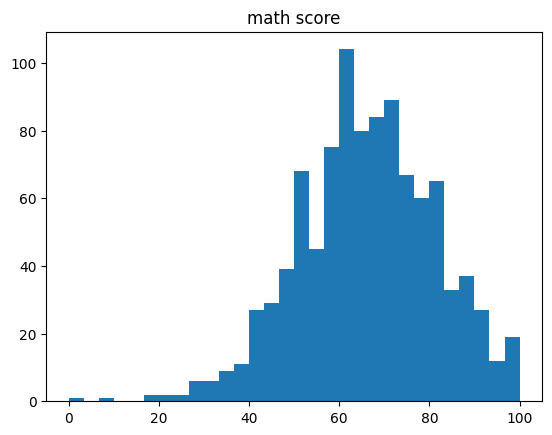

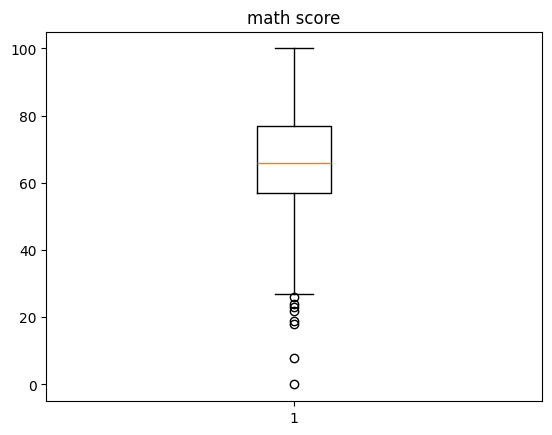

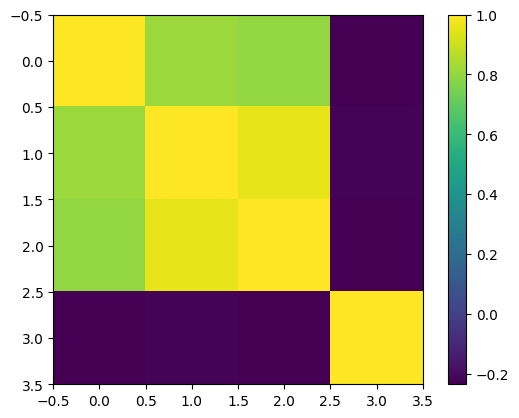

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")   # replace with your file name

df.shape
df.info()
df.head()
df.describe()
missing_pct = df.isnull().mean() * 100
missing_pct.sort_values(ascending=False)

col = "math score"   # change column

plt.hist(df[col], bins=30)
plt.title(col)
plt.show()

plt.boxplot(df[col])
plt.title(col)
plt.show()

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]
outliers.shape

df["outlier_flag"] = np.where(
    (df[col] < lower) | (df[col] > upper),
    1,
    0
)

df[col] = np.where(df[col] > upper, upper,
            np.where(df[col] < lower, lower, df[col]))

corr = df.corr(numeric_only=True)

corr["math score"].sort_values(ascending=False)

plt.imshow(corr)
plt.colorbar()
plt.show()

df.to_csv("cleaned_dataset.csv", index=False)
